# Data Processing and Cycling Infrastructure Classification

West Midlands Combined Authority (WMCA) directed cyclable network construction from OS NGD Transport data. The pipeline moves from study-area and population context, through loading the OS NGD road, path, cycle-lane and highway-dedication layers, to extracting the legally cyclable network, expanding it into directed edges, joining cycle lanes, and classifying facilities into eight LTN 1/20 aligned categories. The result is exported as a directed GeoParquet for downstream LTS classification. Appendix A validates the OS NGD cycle infrastructure against OSM and TfWM for Birmingham.


In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
import io
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib_scalebar.scalebar import ScaleBar

import contextily as ctx

from shapely.geometry import Point, LineString, Polygon
from shapely import wkt
from shapely.wkt import loads

# Allow reading very large single features (OS NGD / ONS boundary GeoJSON)
os.environ["OGR_GEOJSON_MAX_OBJ_SIZE"] = "0"

# Project paths
DATA_DIR = Path('../Data/Raw')
OUTPUT_DIR = Path('../Data/Cleaned')
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

# Coordinate reference systems
CRS_WGS84 = 'EPSG:4326'
CRS_BNG = 'EPSG:27700'  # British National Grid

pd.set_option('display.max_columns', None)

print(f"Working directory: {os.getcwd()}")

Working directory: /Users/pippin/Library/CloudStorage/OneDrive2-UniversityCollegeLondon/Dissertation_CASA&TfWM/Code


## 1. Study Area Boundary

The study area covers the **seven metropolitan boroughs** of the West Midlands Combined Authority (WMCA):
Birmingham, Coventry, Dudley, Sandwell, Solihull, Walsall, and Wolverhampton.

Boundary data source: ONS Local Authority Districts (December 2025), British National Grid (EPSG:27700).

In [3]:
# ── Load boundary datasets ─────────────────────────────────────────
# ONS country + Local Authority District boundaries (Dec 2025), reprojected to BNG.
uk = gpd.read_file(DATA_DIR / 'Countries_December_2023_Boundaries_UK_BFC_4035985682950087633.geojson')
uk_bng = uk.to_crs(CRS_BNG)
england = uk_bng[uk_bng['CTRY23NM'] == 'England']

lad = gpd.read_file(
    DATA_DIR / "Local_Authority_Districts_DEC_2025_Boundaries_UK_BFC_7781342770234899863/LAD_DEC_2025_UK_BFC.shp"
)
print(f"LAD features loaded: {len(lad):,}")

LAD features loaded: 361


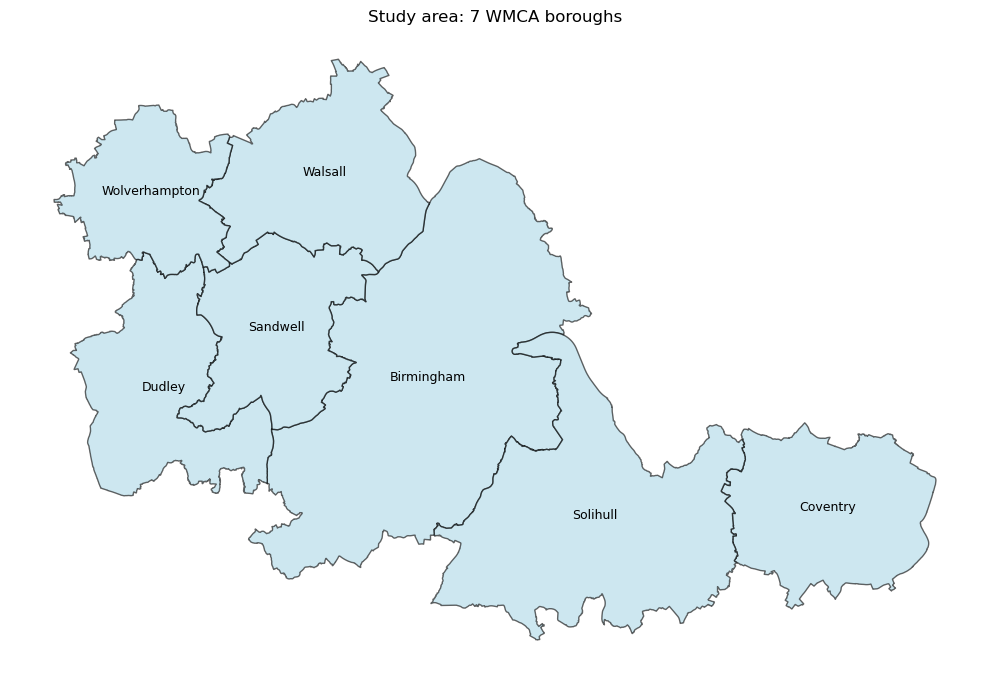

Total study area: 901.7 km²


In [4]:
# ── Define WMCA study area ─────────────────────────────────────────
STUDY_AREA_BOROUGHS = [
    'Birmingham', 'Coventry', 'Dudley', 'Sandwell',
    'Solihull', 'Walsall', 'Wolverhampton',
]

# Filter LAD boundaries to the seven WMCA boroughs, then dissolve to a single outline
study_area = lad[lad['LAD25NM'].isin(STUDY_AREA_BOROUGHS)].to_crs(CRS_BNG).copy()
study_area_union = study_area.unary_union
wmca_outline = gpd.GeoDataFrame(geometry=[study_area_union], crs=CRS_BNG)

# Quick visual check with borough labels
fig, ax = plt.subplots(figsize=(10, 10))
study_area.plot(ax=ax, edgecolor='black', facecolor='lightblue', alpha=0.6)
study_area.apply(lambda r: ax.annotate(
    text=r['LAD25NM'],
    xy=(r.geometry.centroid.x, r.geometry.centroid.y),
    ha='center', fontsize=9
), axis=1)
ax.set_title(f'Study area: {len(STUDY_AREA_BOROUGHS)} WMCA boroughs')
ax.set_axis_off()
plt.tight_layout()
plt.show()

print(f"Total study area: {study_area.geometry.area.sum() / 1e6:.1f} km²")

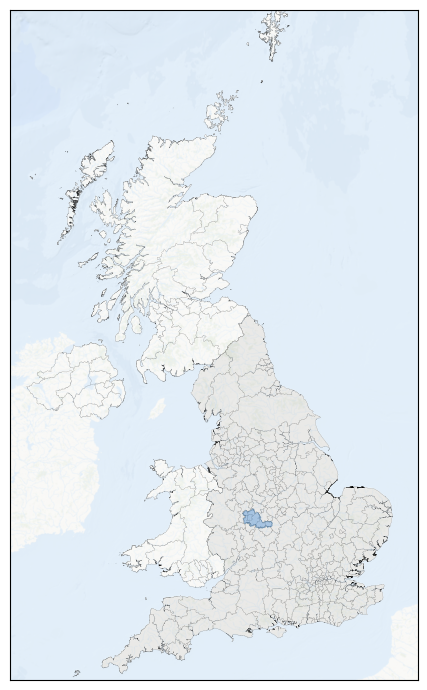

In [5]:
fig, ax = plt.subplots(figsize=(5, 7), facecolor='white')

ax.set_xlim(-30000, 700000)
ax.set_ylim(0, 1200000)

ctx.add_basemap(
    ax,
    crs=wmca_outline.crs,
    source=ctx.providers.Esri.OceanBasemap,
    zoom=7,
    alpha=0.4,        
    attribution=False,
    zorder=2
)

# UK 
uk_bng.plot(ax=ax, facecolor = "none", linewidth=0.1, edgecolor="#060606C4", alpha=0.4, zorder=5)
england.plot(ax=ax, color='#e6e6e6', edgecolor="#FFFFFF", linewidth=0.4, zorder=1)
wmca_outline.plot(ax=ax, color='#4a90d9', edgecolor="#2c5f8a", linewidth=0.5, alpha=0.4, zorder=4)
lad.plot(ax=ax, facecolor='none', edgecolor="#000000A1", linewidth=0.1, alpha=0.4, zorder=3,)

ax.set_xticklabels([])
ax.set_yticklabels([])
ax.tick_params(length=0)
plt.tight_layout()
#plt.savefig("../Figure/study_area_map_1.png", dpi=300, bbox_inches='tight')
plt.show()

In [6]:
# ── Rural-Urban Classification (OA level) ──────────────────────────
oa_ruc = gpd.read_file(DATA_DIR / 'OA_(2021)_EW_BGC_V2_to_Rural_Urban_Classification.geojson')
oa_ruc = oa_ruc.to_crs(CRS_BNG)
oa_ruc_clipped = gpd.overlay(oa_ruc, study_area[['geometry']], how='intersection')

# ── Population (Census 2021) ───────────────────────────────────────
oa_pop = pd.read_csv(DATA_DIR / 'census2021-ts001/census2021-ts001-oa.csv')
oa_pop = oa_pop.rename(columns={
    'geography code': 'OA21CD',
    'Residence type: Total; measures: Value': 'population'
})
oa_ruc_clipped = oa_ruc_clipped.merge(oa_pop[['OA21CD', 'population']], on='OA21CD', how='left')

# Restrict to WMCA boroughs and derive density
oa_ruc_clipped['LAD'] = oa_ruc_clipped['LSOA21NM'].str.rsplit(' ', n=1).str[0]
oa_ruc_clipped = oa_ruc_clipped[oa_ruc_clipped['LAD'].isin(STUDY_AREA_BOROUGHS)]
oa_ruc_clipped['area_km2'] = oa_ruc_clipped.geometry.area / 1e6
oa_ruc_clipped['pop_density'] = oa_ruc_clipped['population'] / oa_ruc_clipped['area_km2']

print(f"OA count: {len(oa_ruc_clipped):,}")
print(f"Total population: {oa_ruc_clipped['population'].sum():,.0f}")
print("\nUrban/Rural split:")
print(oa_ruc_clipped.groupby('Urban_rura')['population'].sum())

OA count: 9,248
Total population: 3,092,670

Urban/Rural split:
Urban_rura
Rural      30345
Urban    3062325
Name: population, dtype: int64


In [7]:
# ── 1. LSOA boundaries (BGC) ──────────────────────────────────────────
lsoa_uk = gpd.read_file(
    DATA_DIR / "Lower_layer_Super_Output_Areas_December_2021_Boundaries_EW_BGC_V5_-3761339731474027792.geojson"
)
lsoa_uk = lsoa_uk.to_crs(CRS_BNG)

# Clip to WMCA via centroid spatial join
lsoa_wm = gpd.sjoin(
    lsoa_uk.assign(centroid=lsoa_uk.geometry.centroid).set_geometry('centroid'),
    study_area[['LAD25NM', 'geometry']],
    predicate='within'
).set_geometry('geometry').drop(columns=['centroid', 'index_right'])

print(f"WM LSOAs: {len(lsoa_wm)}")

# ── 2. Population → density ───────────────────────────────────────────
lsoa_pop = pd.read_csv(DATA_DIR / 'census2021-ts001/census2021-ts001-lsoa.csv')
lsoa_pop = lsoa_pop.rename(columns={
    'geography code': 'LSOA21CD',
    'Residence type: Total; measures: Value': 'population'
})

lsoa_wm = lsoa_wm.merge(lsoa_pop[['LSOA21CD', 'population']], on='LSOA21CD', how='left')
lsoa_wm['area_km2'] = lsoa_wm.geometry.area / 1e6
lsoa_wm['pop_density'] = lsoa_wm['population'] / lsoa_wm['area_km2']

print(f"Total population: {lsoa_wm['population'].sum():,.0f}")
print(f"LSOA count: {len(lsoa_wm)}")
print(lsoa_wm['pop_density'].describe().round(0))

WM LSOAs: 1718
Total population: 2,917,976
LSOA count: 1718
count     1718.0
mean      5269.0
std       3080.0
min         89.0
25%       3357.0
50%       4783.0
75%       6444.0
max      23986.0
Name: pop_density, dtype: float64


Total dots: 291,008 (1 dot = 10 people)


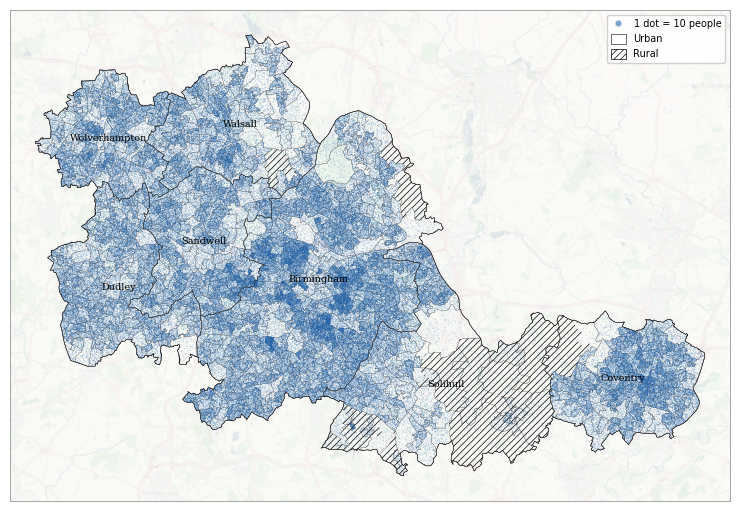

In [12]:
# =============================================================================
# Population dot-density map (1 dot = 10 people) with rural hatching
# =============================================================================
mpl.rcParams['hatch.linewidth'] = 0.5
mpl.rcParams['hatch.color'] = 'black'

one_dot_pop = 10

def random_points_in_polygon(polygon, n):
    """Return n random points uniformly distributed inside a polygon."""
    if n <= 0:
        return []
    points = []
    minx, miny, maxx, maxy = polygon.bounds
    while len(points) < n:
        batch = np.column_stack([
            np.random.uniform(minx, maxx, n * 2),
            np.random.uniform(miny, maxy, n * 2),
        ])
        for x, y in batch:
            if polygon.contains(Point(x, y)):
                points.append((x, y))
                if len(points) >= n:
                    break
    return points

# One dot per `one_dot_pop` residents, placed randomly within each LSOA
np.random.seed(42)
all_x, all_y = [], []
for _, row in lsoa_wm.iterrows():
    for x, y in random_points_in_polygon(row.geometry, int(row['population'] / one_dot_pop)):
        all_x.append(x)
        all_y.append(y)
print(f"Total dots: {len(all_x):,} (1 dot = {one_dot_pop} people)")

fig = plt.figure(figsize=(8, 9), facecolor='white')
ax = fig.add_axes([0.05, 0.08, 0.90, 0.90])

# --- Vectors first: LSOA outlines, population dots, rural hatching ---
lsoa_wm.plot(ax=ax, facecolor='none', edgecolor='#000000', linewidth=0.1, zorder=2)
ax.scatter(all_x, all_y, s=0.3, c='#2166ac', alpha=0.4, edgecolors='none', zorder=3)
rural = oa_ruc_clipped[oa_ruc_clipped['Urban_rura'] == 'Rural']
rural.plot(ax=ax, facecolor=(1, 1, 1, 0), hatch='/////', edgecolor='black', linewidth=0.0, zorder=4)

# Borough boundaries + labels
study_area.plot(ax=ax, facecolor='none', edgecolor='#333333', linewidth=0.3, zorder=5)
study_area.dissolve().boundary.plot(ax=ax, edgecolor='black', linewidth=0.3, zorder=5)
for _, row in study_area.iterrows():
    c = row.geometry.centroid
    ax.text(c.x, c.y, row['LAD25NM'], ha='center', va='center',
            fontsize=7, fontfamily='serif', zorder=6)

# --- Pin the extent to the study-area bounds BEFORE adding the basemap ---
ax.set_aspect('equal')
minx, miny, maxx, maxy = study_area.total_bounds
pad = 2000  # metres
ax.set_xlim(minx - pad, maxx + pad)
ax.set_ylim(miny - pad, maxy + pad)

# --- Basemap underneath (extent is now fixed, so tiles fetch correctly) ---
ctx.add_basemap(ax, crs=lsoa_wm.crs, source=ctx.providers.CartoDB.PositronNoLabels,
                zoom=11, alpha=0.6, attribution=False, zorder=0)
ctx.add_basemap(ax, crs=lsoa_wm.crs, source="https://tile.openstreetmap.org/{z}/{x}/{y}.png",
                zoom=11, alpha=0.1, attribution=False, zorder=0)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('#999999')
    spine.set_linewidth(0.6)
ax.set_xticks([]); ax.set_yticks([])

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2166ac',
           markersize=5, alpha=0.6, label='1 dot = 10 people', linestyle='None'),
    Patch(facecolor='white', edgecolor='#333333', linewidth=0.5, label='Urban'),
    Patch(facecolor='white', edgecolor='black', linewidth=0.5, hatch='/////', label='Rural'),
]

ax.legend(
    handles=legend_elements,
    loc='upper right',
    frameon=True,
    framealpha=0.9,
    edgecolor='#cccccc',
    fontsize=7,
    handlelength=1.5,
    handleheight=1.2,
)

# Re-assert limits in case add_basemap / aspect adjusted them
ax.set_xlim(minx - pad, maxx + pad)
ax.set_ylim(miny - pad, maxy + pad)

# plt.savefig("../Figure/study_area_map_2.png", dpi=300, bbox_inches='tight')
plt.show()

## 2. Load OS NGD Datasets
![OS NGD Transport Theme data structure diagram showing the theme name, collection names, and feature type names.](../Figure/Transport%20Theme%20data%20structure%20diagram-v06.svg)

OS NGD Transport Theme data structure diagram showing the theme name, collection names, and feature type names.

This section loads four OS NGD datasets from the TfWM:

| Dataset | File | Layer Type | Description |
|---|---|---|---|
| **Road Link** | `trn_ntwk_roadlink.zip` | Network (LINESTRING) | Road centrelines with topology, classification, width, gradient, lighting |
| **Path Link** | `trn_ntwk_pathlink.zip` | Network (LINESTRING) | Off-road paths (footpaths, cycleways, bridleways, towpaths) |
| **Cycle Lane** | `trn_ntwk_cyclelane.zip` | Network attribute | On-road cycle infrastructure with type and width |
| **Highway Dedication** | `trn_rami_highwaydedication.zip` | RAMI attribute (CSV) | Legal rights of way — determines cycling legality |

OS NGD separates the transport network into **Road Links** (carriageways) and **Path Links** (off-road routes).
Both must be loaded and combined to form a complete cyclable network.

**Note:** OS NGD CSV/GeoJSON stores geometry as WKT strings requiring `shapely.wkt.loads` parsing.

### 2.1 Road Link (`trn_ntwk_roadlink`)

"A Road Link is a linear spatial object that defines the geometry and connectivity of a road network between two points in the network. Road Links can represent single carriageways, dual carriageways, slip roads, roundabouts, and indicative trajectories across traffic squares. Road Links will be split for connectivity purposes (for example, at junctions) and Road Nodes will connect the Road Links together. Each Road Link will provide a reference to the Road Nodes at the start and end of the Road Link." [(OS, 2026)](https://docs.os.uk/osngd/data-structure/transport/transport-network/road-link)

Key attributes for LTS classification:
- `description`: physical road type (Single Carriageway, Dual Carriageway, Roundabout, etc.)
- `roadclassification`: road hierarchy (Motorway, A Road, B Road, etc.)
- `directionality`: traffic flow direction (Both Directions, In Direction, Against Direction)
- `roadwidth_average` / `roadwidth_minimum`: carriageway width (metres)
- `elevationgain_indirection` / `elevationgain_againstdirection`: height gain for gradient calculation
- `presenceofstreetlight_coverage`: lighting level (Fully Lit, Partially Lit, Not Lit, Unknown)
- `presenceofcyclelane_*`: embedded cycle lane coverage metrics
- `startnode` / `endnode`: node IDs for graph construction

In [5]:
# Load OS NGD Road Link (network topology layer)
os_road_network = gpd.read_file(DATA_DIR / "os_datasets/trn_ntwk_roadlink.zip")
os_road_network["geometry"] = os_road_network["geometry"].apply(wkt.loads)
os_road_network = gpd.GeoDataFrame(os_road_network, geometry="geometry", crs=CRS_BNG)

print(f"Road links loaded: {os_road_network.shape[0]:,} features, {os_road_network.shape[1]} columns")
print(f"Spatial extent (BNG): {os_road_network.total_bounds}")
print(f"\nRoad type distribution:")
print(os_road_network['description'].value_counts())

Road links loaded: 217,416 features, 78 columns
Spatial extent (BNG): [385828.    271845.    439210.944 307229.264]

Road type distribution:
description
Single Carriageway                 184356
Dual Carriageway                    12605
Traffic Island Link At Junction      6549
Roundabout                           5620
Traffic Island Link                  2482
Enclosed Traffic Area                1980
Track                                1949
Slip Road                            1651
Shared Use Carriageway                217
Layby                                   7
Name: count, dtype: int64


### 2.2 Path Link (`trn_ntwk_pathlink`)
A Path Link is a linear spatial object that defines the geometry and connectivity of the Path Network between two points in the network. Path Links will be split for connectivity purposes (for example, at junctions) and Path Nodes will connect the Path Links together. Each Path Link will provide a reference to the Path Nodes at the start and end of the Path Link [(0S, 2026)](https://docs.os.uk/osngd/data-structure/transport/transport-network/path-link).

**Path Links will be captured where:**

- They provide a route that cannot be inferred from the Road Network

- They provide connectivity between Road Networks

- There is a canal path or tow path

- There are paths over footbridges and under subways

**Path Links will not be captured where:**

- They run parallel to the Road Network (for example, a pavement)

- They are connected to a motorway

- There is a physical obstruction which prevents connectivity

- They are non-public paths (for example, in a school, prison, or military area)

- They do not meet validation criteria in place to maintain network quality (for example, isolated links with no connectivity to another link)

Off-road path network, **separate from the road network**. Includes footpaths, bridleways, cycle
tracks, towpaths, footbridges, and subways. Many independent cycleways that appear as
`highway=cycleway` in OSM are captured here.

The `description` field indicates physical form only (e.g. "Path", "Footbridge") — it does NOT
indicate cycling legality. Cycling rights must be determined via Highway Dedication.

In [6]:
# Load OS NGD Path Link
with zipfile.ZipFile(DATA_DIR / "os_datasets/trn_ntwk_pathlink.zip") as z:
    pathlink = pd.read_csv(io.BytesIO(z.read([f for f in z.namelist() if f.endswith('.csv')][0])))

print(f"Path links loaded: {pathlink.shape[0]:,} features, {pathlink.shape[1]} columns")
print(f"\nPath type distribution:")
print(pathlink['description'].value_counts())

Path links loaded: 111,587 features, 43 columns

Path type distribution:
description
Path                        105785
Path With Steps               3632
Footbridge                    1676
Subway                         419
Path With Level Crossing        38
Path With Ford                  37
Name: count, dtype: int64


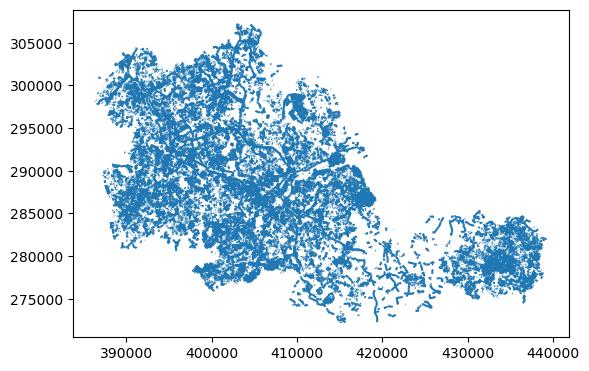

In [7]:
# Convert the geometry column from string to actual geometric objects
# This uses shapely to parse the WKT (Well-Known Text) strings
pathlink['geometry'] = pathlink['geometry'].apply(loads)

# Convert the standard pandas DataFrame into a GeoDataFrame
pathlink = gpd.GeoDataFrame(pathlink, geometry='geometry')

pathlink.geometry.plot()
plt.show()

### 2.3 Cycle Lane (`trn_ntwk_cyclelane`)

Records dedicated cycle infrastructure **associated with Road Links** (on-road lanes, segregated
tracks, shared-use facilities). Each record references a parent Road Link via `linkid`.

Key attributes:
- `description`: infrastructure type (8 categories)
- `cyclelaneinfo_modalwidth_m` / `cyclelaneinfo_minimumwidth_m`: facility width
- `cyclelaneinfo_direction`: directionality of the cycle facility
- `sideoflink`: which side of the road (Left / Right)
- `linkid`: parent Road Link OSID

Does NOT include independent off-road cycleways — those are in Path Link.

In [8]:
# Load OS NGD Cycle Lane
os_cycle_lane = gpd.read_file(DATA_DIR / "os_datasets/trn_ntwk_cyclelane.zip")
os_cycle_lane["geometry"] = os_cycle_lane["geometry"].apply(wkt.loads)
os_cycle_lane = gpd.GeoDataFrame(os_cycle_lane, geometry="geometry", crs=CRS_BNG)

print(f"Cycle lanes loaded: {os_cycle_lane.shape[0]:,} features")
print(f"\nCycle lane type distribution:")
print(os_cycle_lane['description'].value_counts())

Cycle lanes loaded: 9,703 features

Cycle lane type distribution:
description
Unsegregated Shared-Use Cycle Facility    3520
Advisory Cycle Lane On Road               2604
Segregated Shared-Use Cycle Track         2005
Fully Segregated Cycle Track               836
Mandatory Cycle Lane On Road               456
Lightly Segregated Cycle Lane On Road      162
Stepped Cycle Track Along Road             111
Unknown Type Of Cycle Track Or Lane          9
Name: count, dtype: int64


### 2.4 Highway Dedication (`trn_rami_highwaydedication`)

Records the **legal status** of each road/path segment under UK highway law.

The dataset consists of two tables:
- `trn_rami_highwaydedication.csv` — dedication records with `osid` and `description`
- `trn_rami_highwaydedication_hwydedntwkref.csv` — reference table linking dedications to
  network links via `networkreferenceid` (matches Road/Path Link `osid`)

Join path: `hd_ref.highwaydedicationid → hd.osid` then `hd_ref.networkreferenceid → link.osid`

In [9]:
# Load Highway Dedication (two CSVs in one zip)
zip_path = DATA_DIR / "os_datasets/trn_rami_highwaydedication.zip"

with zipfile.ZipFile(zip_path) as z:
    hd = pd.read_csv(io.BytesIO(z.read("trn_rami_highwaydedication.csv")))
    hd_ref = pd.read_csv(io.BytesIO(z.read("trn_rami_highwaydedication_hwydedntwkref.csv")))

print(f"Highway Dedication records: {hd.shape[0]:,}")
print(f"Network references: {hd_ref.shape[0]:,} ({hd_ref['networkreferenceid'].nunique():,} unique links)")
print(f"\nDedication type distribution:")
print(hd['description'].value_counts())

Highway Dedication records: 114,540
Network references: 346,617 (236,813 unique links)

Dedication type distribution:
description
All Vehicles                           103297
Pedestrian Way Or Footpath               7335
No Dedication Or Dedication Unknown      3009
Motorway                                  719
Cycle Track Or Cycle Way                  138
Restricted Byway                           35
Byway Open To All Traffic                   4
Bridleway                                   3
Name: count, dtype: int64


## 3. Join Highway Dedication to Network Links

Highway Dedication is joined to **both** Road Links and Path Links via the reference table.

Where one link has multiple HD records (e.g. historical changes), only the first match is kept.

In [10]:
# =============================================================================
# Join Highway Dedication to Road Links and Path Links
# =============================================================================

# --- Merge HD reference table with dedication descriptions ---
hd_merged = hd_ref.merge(
    hd[['osid', 'description']],
    left_on='highwaydedicationid',
    right_on='osid',
    how='left'
)

# Deduplicate: keep one dedication per network link
hd_lookup = (
    hd_merged[['networkreferenceid', 'description']]
    .drop_duplicates('networkreferenceid')
    .rename(columns={'description': 'highway_dedication'})
)

# --- Join to Road Links ---
roadlink_with_ded = os_road_network.merge(
    hd_lookup, left_on='osid', right_on='networkreferenceid', how='left'
)

print("ROAD LINKS — Highway Dedication join:")
print(f"  With HD record:    {roadlink_with_ded['highway_dedication'].notna().sum():,}")
print(f"  Without HD record: {roadlink_with_ded['highway_dedication'].isna().sum():,}")
print(roadlink_with_ded['highway_dedication'].value_counts(dropna=False))

# --- Join to Path Links ---
pathlink_with_ded = pathlink.merge(
    hd_lookup, left_on='osid', right_on='networkreferenceid', how='left'
)

print(f"\nPATH LINKS — Highway Dedication join:")
print(f"  With HD record:    {pathlink_with_ded['highway_dedication'].notna().sum():,}")
print(f"  Without HD record: {pathlink_with_ded['highway_dedication'].isna().sum():,}")
print(pathlink_with_ded['highway_dedication'].value_counts(dropna=False))

ROAD LINKS — Highway Dedication join:
  With HD record:    183,550
  Without HD record: 33,866
highway_dedication
All Vehicles                           178821
NaN                                     33866
No Dedication Or Dedication Unknown      3461
Motorway                                  649
Pedestrian Way Or Footpath                518
Restricted Byway                           75
Cycle Track Or Cycle Way                   22
Byway Open To All Traffic                   4
Name: count, dtype: int64

PATH LINKS — Highway Dedication join:
  With HD record:    16,011
  Without HD record: 95,576
highway_dedication
NaN                                    95576
Pedestrian Way Or Footpath             11026
All Vehicles                            4047
No Dedication Or Dedication Unknown      452
Cycle Track Or Cycle Way                 439
Restricted Byway                          32
Motorway                                   7
Bridleway                                  6
Byway Open To All 

## 4. Cycleable Network Extraction

This section extracts all legally and practically cyclable segments from the West Midlands
transport network. Cyclable infrastructure is represented in two feature collections:
**Road Links** (carriageway network) and **Path Links** (routes topologically independent
from the carriageway).

The legal cyclability of segments is firstly checked through the **Highway Dedication**
feature collection, which records one of eight designation types under UK highway law.
Five permit cycling; `Motorway` and `Pedestrian Way Or Footpath` are excluded.

| Designation | Cyclable? | Legal Basis |
|---|---|---|
| All Vehicles | Yes | Public roads — cycling permitted by default |
| Cycle Track Or Cycle Way | Yes | Cycle Tracks Act 1984 |
| Bridleway | Yes | Countryside Act 1968, s.30 |
| Restricted Byway | Yes | Countryside and Rights of Way Act 2000 |
| Byway Open To All Traffic | Yes | Wildlife and Countryside Act 1981, s.66(1) |
| Motorway | No | Motorways Traffic Regulations 1982 |
| Pedestrian Way Or Footpath | No | No public right of way for cycling |




> **Note:** The eighth type, `No Dedication Or Dedication Unknown`, is neither cyclable
> nor explicitly non-cyclable and is addressed through the description-based fallback
> classification for Road Links.


### 4.1 Cyclable Road Links

For Road Links, Highway Dedication covers most segments. Where a dedication record is
absent or recorded as `No Dedication Or Dedication Unknown`, a fallback classification
retains segments whose physical `description` indicates a carriageway type, on the basis
that an undesignated carriageway more likely reflects incomplete administrative records
than a legal prohibition on cycling. Segments classified as `Motorway` are excluded
regardless of dedication status.


In [11]:
# =============================================================================
# 4.1 Cycleable Road Links
# =============================================================================

# --- Define cycleable / non-cycleable dedication types ---
cycleable_dedications = [
    'All Vehicles',                        # Public roads, cycling permitted by default
    'Cycle Track Or Cycle Way',            # Cycle Tracks Act 1984
    'Bridleway',                           # Countryside Act 1968, Section 30
    'Restricted Byway',                    # Non-mechanically propelled vehicles permitted
    'Byway Open To All Traffic',           # All traffic including cycling (RTRA 1984)
]

non_cycleable_dedications = [
    'Motorway',                            # Cycling prohibited by law
    'Pedestrian Way Or Footpath',          # Highways Act 1835, Section 72
]

# (a) Road links with cycleable HD
has_ded = roadlink_with_ded[roadlink_with_ded['highway_dedication'].notna()]
cycleable_roads_by_ded = has_ded[has_ded['highway_dedication'].isin(cycleable_dedications)]

# (b) Fallback: road links without HD → classify by physical description
cycleable_descriptions = [
    'Single Carriageway', 'Dual Carriageway', 'Roundabout', 'Slip Road',
    'Shared Use Carriageway', 'Traffic Island Link At Junction', 'Traffic Island Link',
]
no_ded = roadlink_with_ded[
    (roadlink_with_ded['highway_dedication'].isna()) |
    (roadlink_with_ded['highway_dedication'] == 'No Dedication Or Dedication Unknown')
]
cycleable_roads_by_desc = no_ded[
    (no_ded['description'].isin(cycleable_descriptions)) &
    (no_ded['roadclassification'] != 'Motorway')
]

# (c) Combine and remove any remaining motorway segments
cycleable_roads = pd.concat([cycleable_roads_by_ded, cycleable_roads_by_desc], ignore_index=True)
cycleable_roads = cycleable_roads[cycleable_roads['roadclassification'] != 'Motorway']
cycleable_roads['link_type'] = 'road'

# Count AFTER final filter
mask_ded = cycleable_roads['highway_dedication'].isin(cycleable_dedications)
n_by_ded = mask_ded.sum()
n_by_desc = (~mask_ded).sum()
n_total_roads = roadlink_with_ded.shape[0]

print(f"Total road links: {n_total_roads:,}")
print(f"Cycleable road links: {cycleable_roads.shape[0]:,} ({cycleable_roads.shape[0]/n_total_roads*100:.1f}%)")
print(f"  By HD record:      {n_by_ded:,} ({n_by_ded/cycleable_roads.shape[0]*100:.1f}%)")
print(f"  By description:    {n_by_desc:,} ({n_by_desc/cycleable_roads.shape[0]*100:.1f}%)")

Total road links: 217,416
Cycleable road links: 212,551 (97.8%)
  By HD record:      178,863 (84.2%)
  By description:    33,688 (15.8%)


### 4.2 Cyclable Path Links

For Path Links, Highway Dedication coverage is substantially lower. No attribute in
the OS NGD Path Link schema provides a direct cyclability indicator.

Three layers are used:
1. **Highway Dedication** — paths with a cyclable HD record.
2. **Cycle lane presence** — paths where `presenceofcyclelane_overallpercentage > 0`.
3. **OSM cross-validation** — remaining paths matched to OpenStreetMap cycling
   geometries within a 5m nearest-neighbour spatial join. This follows the DfT
   transport connectivity metric precedent of using OSM for active travel
   network construction (DfT, 2025).

Paths with explicitly non-cyclable Highway Dedications are excluded at all layers.


In [12]:
# =============================================================================
# 4.2 Cycleable Path Links
# =============================================================================

# Layer 1: HD cycleable
include_by_hd = pathlink_with_ded['highway_dedication'].isin(cycleable_dedications)

# Layer 2: OS detected cycle facility
include_by_facility = pathlink_with_ded['presenceofcyclelane_overallpercentage'] > 0

# Layer 3: OSM cross-validation for no-HD paths
osm_cycling = gpd.read_parquet(DATA_DIR / "cycling_network_processed.parquet")
osm_cycling = osm_cycling.to_crs(CRS_BNG)

# Ensure pathlink is a GeoDataFrame (geometry may already be parsed from Cell 10)
pathlink_geo = pathlink_with_ded.copy()
if not isinstance(pathlink_geo, gpd.GeoDataFrame):
    pathlink_geo['geometry'] = pathlink_geo['geometry'].apply(wkt.loads)
    pathlink_geo = gpd.GeoDataFrame(pathlink_geo, geometry='geometry', crs=CRS_BNG)
elif pathlink_geo.crs is None:
    pathlink_geo = pathlink_geo.set_crs(CRS_BNG)

# Filter: only paths without HD and not already captured by layer 1 & 2
no_hd_mask = pathlink_with_ded['highway_dedication'].isna()
already_included = include_by_hd | include_by_facility
needs_osm = no_hd_mask & ~already_included

no_hd_paths = pathlink_geo[needs_osm]

# Spatial join: match OS paths to OSM cycling network within 5m
osm_matched = gpd.sjoin_nearest(
    no_hd_paths[['osid', 'geometry']],
    osm_cycling[['geometry']],
    how='inner',
    max_distance=5,
    distance_col='match_dist'
)
osm_matched_ids = set(osm_matched['osid'].unique())
include_by_osm = pathlink_with_ded['osid'].isin(osm_matched_ids)

# Definite exclude: HD non-cycleable (even if OSM/facility says otherwise)
exclude_by_hd = pathlink_with_ded['highway_dedication'].isin(non_cycleable_dedications)

# --- Combine all layers ---
cycleable_mask = (include_by_hd | include_by_facility | include_by_osm) & ~exclude_by_hd
cycleable_paths = pathlink_geo[cycleable_mask].copy()
cycleable_paths['link_type'] = 'path'

# Count AFTER final filter
mask_hd = cycleable_paths['osid'].isin(pathlink_with_ded[include_by_hd]['osid'])
mask_facility = cycleable_paths['osid'].isin(pathlink_with_ded[include_by_facility & ~include_by_hd]['osid'])
mask_osm = ~mask_hd & ~mask_facility

n_by_hd = mask_hd.sum()
n_by_facility = mask_facility.sum()
n_by_osm = mask_osm.sum()
n_total_paths = pathlink_with_ded.shape[0]
n_cycleable = cycleable_paths.shape[0]

print("=" * 60)
print("CYCLEABLE PATH LINK CLASSIFICATION")
print("=" * 60)
print(f"Total path links: {n_total_paths:,}")
print(f"Cycleable path links: {n_cycleable:,} ({n_cycleable/n_total_paths*100:.1f}%)")
print(f"  By HD record:          {n_by_hd:,} ({n_by_hd/n_cycleable*100:.1f}%)")
print(f"  By cycle facility:     {n_by_facility:,} ({n_by_facility/n_cycleable*100:.1f}%)")
print(f"  By OSM cross-validation: {n_by_osm:,} ({n_by_osm/n_cycleable*100:.1f}%)")
print(f"Excluded: {n_total_paths - n_cycleable:,} ({(n_total_paths - n_cycleable)/n_total_paths*100:.1f}%)")

CYCLEABLE PATH LINK CLASSIFICATION
Total path links: 111,587
Cycleable path links: 45,023 (40.3%)
  By HD record:          4,526 (10.1%)
  By cycle facility:     462 (1.0%)
  By OSM cross-validation: 40,035 (88.9%)
Excluded: 66,564 (59.7%)


## 5. Directed Edge Expansion

OS NGD models roads as **undirected links** with a `directionality` attribute indicating
permitted travel directions. For direction-aware analysis (cycle lane assignment,
gradient, junction approach), each link is expanded into one or two **directed edges**:

| `directionality` | Expansion | `edge_dir` |
|---|---|---|
| Both Directions | 2 edges | `forward` + `backward` |
| In Direction | 1 edge | `forward` |
| In Opposite Direction | 1 edge | `backward` |

For **forward** edges, `startnode` → `endnode` follows the digitised geometry direction.
For **backward** edges, the node pair is swapped (`endnode` → `startnode`) and
elevation gain is reversed.

**Path Links** have no `directionality` attribute and are always bidirectional;
they are expanded into forward + backward edges unconditionally.

In [13]:
# =============================================================================
# 5a. Expand Road Links into Directed Edges
# =============================================================================

def expand_directed_edges(gdf):
    """
    Expand undirected links into directed edges (vectorised).
    
    Road links use `directionality`:
      - 'Both Directions'        → forward + backward
      - 'In Direction'            → forward only
      - 'In Opposite Direction'   → backward only
    
    Links without `directionality` (path links) → forward + backward.
    """
    has_dir = 'directionality' in gdf.columns
    has_nodes = {'startnode', 'endnode'}.issubset(gdf.columns)
    has_elev = {'elevationgain_indirection', 'elevationgain_againstdirection'}.issubset(gdf.columns)
    
    if has_dir:
        fwd_mask = gdf['directionality'].isin(['Both Directions', 'In Direction'])
        bwd_mask = gdf['directionality'].isin(['Both Directions', 'In Opposite Direction'])
    else:
        fwd_mask = bwd_mask = pd.Series(True, index=gdf.index)
    
    # Build forward edges
    fwd = gdf.loc[fwd_mask].copy()
    fwd['edge_dir'] = 'forward'
    fwd['edge_id'] = fwd['osid'].astype(str) + '_F'
    if has_nodes:
        fwd['from_node'] = fwd['startnode']
        fwd['to_node'] = fwd['endnode']
    if has_elev:
        fwd['elevation_gain'] = fwd['elevationgain_indirection']
    
    # Build backward edges
    bwd = gdf.loc[bwd_mask].copy()
    bwd['edge_dir'] = 'backward'
    bwd['edge_id'] = bwd['osid'].astype(str) + '_B'
    if has_nodes:
        bwd['from_node'] = bwd['endnode']     # swapped
        bwd['to_node'] = bwd['startnode']     # swapped
    if has_elev:
        bwd['elevation_gain'] = bwd['elevationgain_againstdirection']
    
    result = gpd.GeoDataFrame(
        pd.concat([fwd, bwd], ignore_index=True),
        geometry='geometry', crs=gdf.crs
    )
    return result


# Expand road links
directed_roads = expand_directed_edges(cycleable_roads)

# --- Summary ---
print('=' * 60)
print('DIRECTED ROAD EDGES')
print('=' * 60)
print(f'Input road links:  {cycleable_roads.shape[0]:,}')
print(f'Output edges:      {directed_roads.shape[0]:,}')
print(f'\nDirectionality distribution (original):')
print(cycleable_roads['directionality'].value_counts(dropna=False))
print(f'\nEdge direction distribution (expanded):')
print(directed_roads['edge_dir'].value_counts())

DIRECTED ROAD EDGES
Input road links:  212,551
Output edges:      390,182

Directionality distribution (original):
directionality
Both Directions          177631
In Direction              19795
In Opposite Direction     15125
Name: count, dtype: int64

Edge direction distribution (expanded):
edge_dir
forward     197426
backward    192756
Name: count, dtype: int64


In [14]:
# =============================================================================
# 5b. Expand Path Links into Directed Edges
# =============================================================================

directed_paths = expand_directed_edges(cycleable_paths)

print('=' * 60)
print('DIRECTED PATH EDGES')
print('=' * 60)
print(f'Input path links:  {cycleable_paths.shape[0]:,}')
print(f'Output edges:      {directed_paths.shape[0]:,}')
print(f'\nEdge direction distribution:')
print(directed_paths['edge_dir'].value_counts())

DIRECTED PATH EDGES
Input path links:  45,023
Output edges:      90,046

Edge direction distribution:
edge_dir
forward     45023
backward    45023
Name: count, dtype: int64


## 6. Directed Cycle Lane Join

Each directed road edge is matched to the cycle lane record that applies to its
travel direction. The matching rule uses the cycle lane's `cyclelaneinfo_direction`:

| Edge direction | Matches cycle lane `cyclelaneinfo_direction` |
|---|---|
| `forward` | `In Direction` or `Both Directions` |
| `backward` | `In Opposite Direction` or `Both Directions` |

Where multiple cycle lanes match the same edge (e.g. an advisory lane and a
segregated track on the same link and direction), the facility with the highest
degree of separation from motor traffic is retained — this follows the principle
that the best available facility determines the cyclist's experience on that edge.

In [15]:
# =============================================================================
# 6. Directed Cycle Lane Join
# =============================================================================

cl_cols = ['linkid', 'description', 'cyclelaneinfo_modalwidth_m',
           'cyclelaneinfo_minimumwidth_m', 'cyclelaneinfo_direction',
           'sideoflink']

# --- Step 1: Split cycle lane records by applicable direction ---
forward_mask = os_cycle_lane['cyclelaneinfo_direction'].isin(
    ['In Direction', 'Both Directions']
)
backward_mask = os_cycle_lane['cyclelaneinfo_direction'].isin(
    ['In Opposite Direction', 'Both Directions']
)

cl_fwd = os_cycle_lane.loc[forward_mask, cl_cols].copy()
cl_fwd['edge_dir'] = 'forward'

cl_bwd = os_cycle_lane.loc[backward_mask, cl_cols].copy()
cl_bwd['edge_dir'] = 'backward'

cl_directed = pd.concat([cl_fwd, cl_bwd], ignore_index=True).rename(
    columns={'description': 'cyclelane_type'}
)

print(f'Cycle lane records: {os_cycle_lane.shape[0]:,}')
print(f'  Forward-applicable:  {cl_fwd.shape[0]:,}')
print(f'  Backward-applicable: {cl_bwd.shape[0]:,}')
print(f'  Total directed:      {cl_directed.shape[0]:,}')
print(f'\ncyclelaneinfo_direction distribution:')
print(os_cycle_lane['cyclelaneinfo_direction'].value_counts(dropna=False))

# --- Step 2: Deduplicate — keep best facility per link × direction ---
facility_rank = {
    'Fully Segregated Cycle Track':           1,
    'Segregated Shared-Use Cycle Track':      2,
    'Unsegregated Shared-Use Cycle Facility': 3,
    'Stepped Cycle Track Along Road':         4,
    'Lightly Segregated Cycle Lane On Road':  5,
    'Mandatory Cycle Lane On Road':           6,
    'Advisory Cycle Lane On Road':            7,
    'Unknown Type Of Cycle Track Or Lane':    8,
}
cl_directed['_rank'] = cl_directed['cyclelane_type'].map(facility_rank)
cl_directed = (
    cl_directed
    .sort_values('_rank')
    .drop_duplicates(subset=['linkid', 'edge_dir'], keep='first')
    .drop(columns='_rank')
)

print(f'\nAfter dedup: {cl_directed.shape[0]:,} directed cycle lane records')

# --- Step 3: Join to directed road edges ---
directed_roads_cl = directed_roads.merge(
    cl_directed,
    left_on=['osid', 'edge_dir'],
    right_on=['linkid', 'edge_dir'],
    how='left'
)

# --- Validation ---
assert directed_roads_cl.shape[0] == directed_roads.shape[0], (
    f'Row inflation! {directed_roads.shape[0]:,} → {directed_roads_cl.shape[0]:,}'
)

print(f'\n{"=" * 60}')
print(f'DIRECTED ROAD EDGES AFTER CYCLE LANE JOIN')
print(f'{"=" * 60}')
print(f'Total directed edges: {directed_roads_cl.shape[0]:,} (no row inflation ✓)')
print(f'  With cycle lane:  {directed_roads_cl["cyclelane_type"].notna().sum():,}')
print(f'  Mixed traffic:    {directed_roads_cl["cyclelane_type"].isna().sum():,}')
print(f'\nCycle lane type × edge direction:')
print(pd.crosstab(
    directed_roads_cl['cyclelane_type'].fillna('(no cycle lane)'),
    directed_roads_cl['edge_dir'],
    margins=True
))

Cycle lane records: 9,703
  Forward-applicable:  9,703
  Backward-applicable: 6,241
  Total directed:      15,944

cyclelaneinfo_direction distribution:
cyclelaneinfo_direction
Both Directions    6241
In Direction       3462
Name: count, dtype: int64

After dedup: 11,104 directed cycle lane records

DIRECTED ROAD EDGES AFTER CYCLE LANE JOIN
Total directed edges: 390,182 (no row inflation ✓)
  With cycle lane:  6,847
  Mixed traffic:    383,335

Cycle lane type × edge direction:
edge_dir                                backward  forward     All
cyclelane_type                                                   
(no cycle lane)                           190216   193119  383335
Advisory Cycle Lane On Road                   82     1050    1132
Fully Segregated Cycle Track                 224      457     681
Lightly Segregated Cycle Lane On Road         50       96     146
Mandatory Cycle Lane On Road                   2      146     148
Segregated Shared-Use Cycle Track            714      8

## 7. Cycling Infrastructure Classification

Each directed edge is classified into one of **eight facility types** derived from
LTN 1/20's design hierarchy.

### Classification Rules

**Road edges**: mapped from the OS Cycle Lane type joined in Section 6.
Edges without a matching cycle lane record are classified as **Mixed Traffic**.

**Path edges**: all classified as **Off-Road** (traffic-free by definition).

In [16]:
# =============================================================================
# 7. Cycling Infrastructure Classification (8 Categories)
# =============================================================================

# --- 7a. Classify directed ROAD edges ---
os_to_facility = {
    'Fully Segregated Cycle Track':           'Fully Kerbed Cycle Track',
    'Unsegregated Shared-Use Cycle Facility': 'Shared Use',
    'Segregated Shared-Use Cycle Track':      'Shared Use',
    'Stepped Cycle Track Along Road':         'Stepped Cycle Track',
    'Lightly Segregated Cycle Lane On Road':  'Light Segregation',
    'Mandatory Cycle Lane On Road':           'Mandatory Cycle Lane',
    'Advisory Cycle Lane On Road':            'Advisory Cycle Lane',
    'Unknown Type Of Cycle Track Or Lane':    'Mixed Traffic',
}

directed_roads_cl['facility_type'] = (
    directed_roads_cl['cyclelane_type']
    .map(os_to_facility)
    .fillna('Mixed Traffic')
)

print('ROAD EDGES — Facility type distribution:')
print(directed_roads_cl['facility_type'].value_counts())
print(f'\nFacility type × edge direction:')
print(pd.crosstab(directed_roads_cl['facility_type'], directed_roads_cl['edge_dir']))

# --- 7b. Classify directed PATH edges ---
directed_paths['facility_type'] = 'Off-Road'

print(f'\nPATH EDGES — All {directed_paths.shape[0]:,} classified as Off-Road')

# --- 7c. Directed km by facility type (roads + paths combined) ---
all_edges = pd.concat([directed_roads_cl, directed_paths], ignore_index=True)
all_edges['geometry_length_m'] = pd.to_numeric(all_edges['geometry_length_m'], errors='coerce')

km_by_type = (
    all_edges
    .groupby('facility_type')['geometry_length_m']
    .sum()
    .div(1000)
    .sort_values(ascending=False)
)

print(f'\n{"=" * 60}')
print('DIRECTED KM BY FACILITY TYPE')
print(f'{"=" * 60}')
for ft, km in km_by_type.items():
    print(f'  {ft:35s} {km:>10,.1f} km  ({km / km_by_type.sum() * 100:5.1f}%)')
print(f'  {"TOTAL":35s} {km_by_type.sum():>10,.1f} km')

ROAD EDGES — Facility type distribution:
facility_type
Mixed Traffic               383335
Shared Use                    4668
Advisory Cycle Lane           1132
Fully Kerbed Cycle Track       681
Mandatory Cycle Lane           148
Light Segregation              146
Stepped Cycle Track             72
Name: count, dtype: int64

Facility type × edge direction:
edge_dir                  backward  forward
facility_type                              
Advisory Cycle Lane             82     1050
Fully Kerbed Cycle Track       224      457
Light Segregation               50       96
Mandatory Cycle Lane             2      146
Mixed Traffic               190216   193119
Shared Use                    2155     2513
Stepped Cycle Track             27       45

PATH EDGES — All 90,046 classified as Off-Road

DIRECTED KM BY FACILITY TYPE
  Mixed Traffic                         18,934.9 km  ( 81.3%)
  Off-Road                               4,014.1 km  ( 17.2%)
  Shared Use                               

## 8. Combine into Unified Directed Network

Road edges and path edges are merged into a single GeoDataFrame.
Each record is a **directed edge** with:
- `edge_id`: unique identifier (`{osid}_F` or `{osid}_B`)
- `edge_dir`: travel direction (`forward` or `backward`)
- `from_node` / `to_node`: directed node pair for graph construction
- `facility_type`: one of 8 LTN 1/20 aligned categories
- `traffic_interaction`: `traffic_free` or `on_highway`

In [25]:
# =============================================================================
# 8. Combine into Unified Directed Cycleable Network
# =============================================================================

# Ensure both are GeoDataFrames with consistent CRS
for gdf in [directed_roads_cl, directed_paths]:
    if not isinstance(gdf, gpd.GeoDataFrame):
        raise TypeError('Expected GeoDataFrame')
    if gdf.crs is None:
        gdf.set_crs(CRS_BNG, inplace=True)

# Combine
cycleable_network = pd.concat(
    [directed_roads_cl, directed_paths], ignore_index=True
)
cycleable_network = gpd.GeoDataFrame(cycleable_network, geometry='geometry', crs=CRS_BNG)

# Assign LTS assessment branch
traffic_free_types = ['Off-Road', 'Shared Use', 'Fully Kerbed Cycle Track']
cycleable_network['traffic_interaction'] = cycleable_network['facility_type'].apply(
    lambda x: 'traffic_free' if x in traffic_free_types else 'on_highway'
)

# --- Summary ---
print('=' * 60)
print('UNIFIED DIRECTED CYCLEABLE NETWORK')
print('=' * 60)
print(f'Total directed edges: {cycleable_network.shape[0]:,}')
print(f'  Road edges: {(cycleable_network["link_type"] == "road").sum():,}')
print(f'  Path edges: {(cycleable_network["link_type"] == "path").sum():,}')
print(f'\nFacility type distribution:')
print(cycleable_network['facility_type'].value_counts())
print(f'\nLTS branch distribution:')
print(cycleable_network['traffic_interaction'].value_counts())
print(f'\nFacility type × edge direction:')
print(pd.crosstab(
    cycleable_network['facility_type'],
    cycleable_network['edge_dir'],
    margins=True
))

UNIFIED DIRECTED CYCLEABLE NETWORK
Total directed edges: 480,228
  Road edges: 390,182
  Path edges: 90,046

Facility type distribution:
facility_type
Mixed Traffic               383335
Off-Road                     90046
Shared Use                    4668
Advisory Cycle Lane           1132
Fully Kerbed Cycle Track       681
Mandatory Cycle Lane           148
Light Segregation              146
Stepped Cycle Track             72
Name: count, dtype: int64

LTS branch distribution:
traffic_interaction
on_highway      384833
traffic_free     95395
Name: count, dtype: int64

Facility type × edge direction:
edge_dir                  backward  forward     All
facility_type                                      
Advisory Cycle Lane             82     1050    1132
Fully Kerbed Cycle Track       224      457     681
Light Segregation               50       96     146
Mandatory Cycle Lane             2      146     148
Mixed Traffic               190216   193119  383335
Off-Road                    

## 9. Visualisation: Cyclable Network by Facility Type

In [26]:
cycleable_network_clipped = cycleable_network.clip(study_area_union)

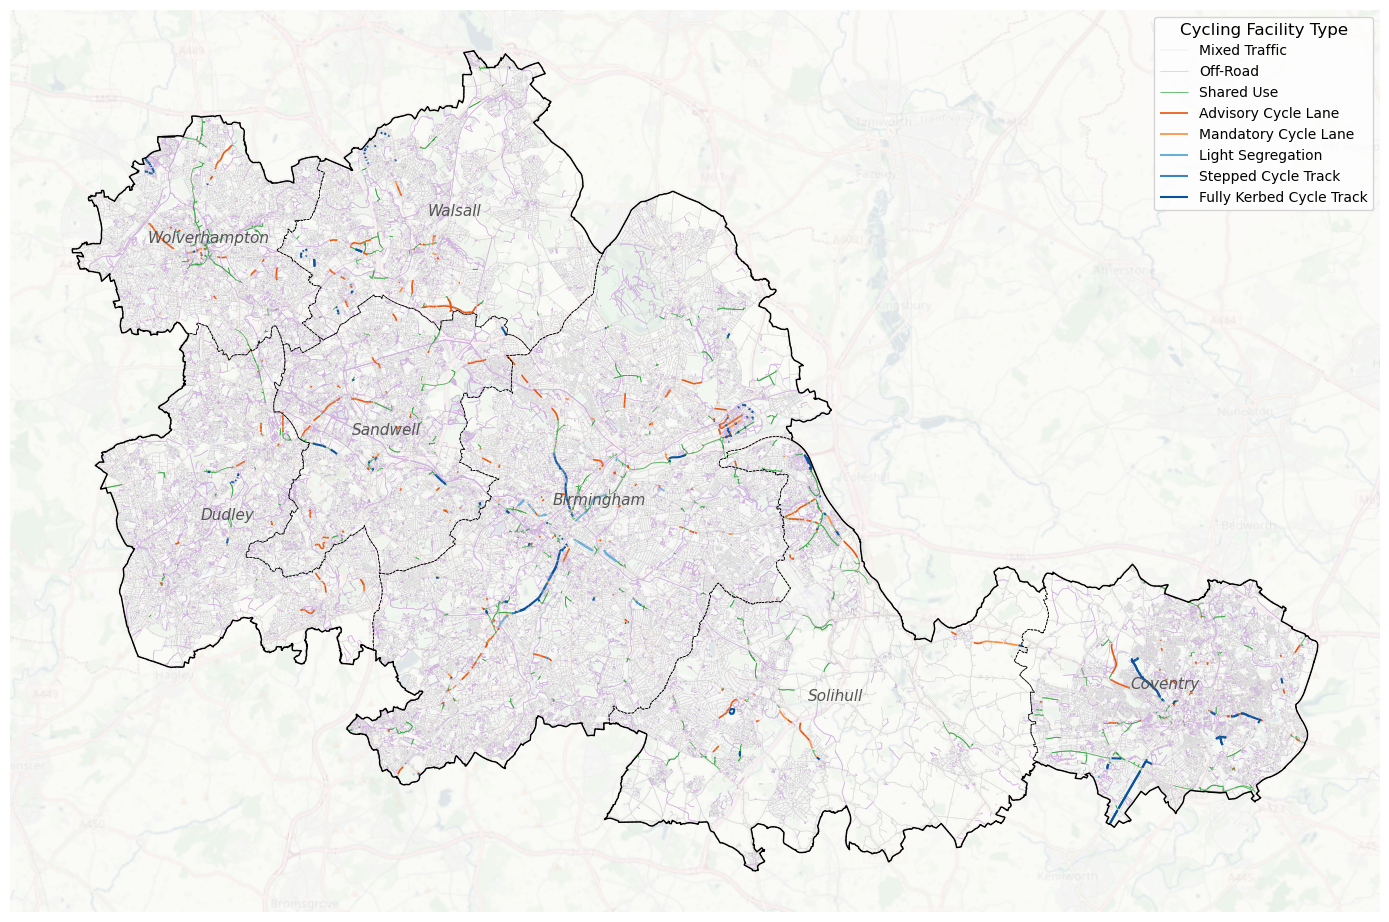

In [ ]:
# =============================================================================
# Plot cycleable network by facility type (8 categories)
# =============================================================================

fig, ax = plt.subplots(figsize=(14, 11))

facility_colors = {
    'Mixed Traffic':             '#d9d9d9',
    'Off-Road':                  "#d2b2df",   
    'Shared Use':                "#25A134C8",   
    'Fully Kerbed Cycle Track':  '#08519c',   
    'Stepped Cycle Track':       "#2170b5de",  
    'Light Segregation':         '#6baed6',   
    'Mandatory Cycle Lane':      '#fd8d3c',   
    'Advisory Cycle Lane':       '#e6550d',   
}

facility_lw = {
    'Mixed Traffic':             0.3,
    'Off-Road':                  0.4,
    'Shared Use':                0.6,
    'Fully Kerbed Cycle Track':  1.5,
    'Stepped Cycle Track':       1.5,
    'Light Segregation':         1.5,
    'Mandatory Cycle Lane':      1.2,
    'Advisory Cycle Lane':       1.2,
}

plot_order = [
    'Mixed Traffic',
    'Off-Road', 'Shared Use',
    'Advisory Cycle Lane', 'Mandatory Cycle Lane',
    'Light Segregation', 'Stepped Cycle Track',
    'Fully Kerbed Cycle Track',
]

for ftype in plot_order:
    subset = cycleable_network_clipped[cycleable_network_clipped['facility_type'] == ftype]
    if len(subset) > 0:
        subset.plot(ax=ax, color=facility_colors[ftype],
                    linewidth=facility_lw[ftype], label=ftype)

study_area.boundary.plot(ax=ax, edgecolor='black', linewidth=0.5, linestyle='--')

gpd.GeoSeries([study_area_union], crs=study_area.crs).boundary.plot(
    ax=ax, edgecolor='black', linewidth=1, linestyle='-'
)

study_area.apply(lambda r: ax.annotate(
    text=r['LAD25NM'],
    xy=(r.geometry.centroid.x, r.geometry.centroid.y),
    ha='center', fontsize=11, color='#555555', fontstyle='italic'
), axis=1)

ax.legend(loc='upper right', title='Cycling Facility Type', fontsize=10, title_fontsize=12,
          ncol=1)

# --- Basemap underneath (extent is now fixed, so tiles fetch correctly) ---
ctx.add_basemap(ax, crs=lsoa_wm.crs, source=ctx.providers.CartoDB.PositronNoLabels,
                zoom=11, alpha=0.6, attribution=False, zorder=0)
ctx.add_basemap(ax, crs=lsoa_wm.crs, source="https://tile.openstreetmap.org/{z}/{x}/{y}.png",
                zoom=11, alpha=0.1, attribution=False, zorder=0)

#ax.set_title('West Midlands Cyclable Network by Facility Type (8 Categories)', fontsize=15)

ax.set_axis_off()
plt.tight_layout()
#plt.savefig("../Figure/wm_facility_types.png", dpi=300, bbox_inches='tight')
plt.show()

In [31]:
# Check: same original link, different facility types per direction?
link_facilities = (
    cycleable_network
    .groupby('networkreferenceid')['facility_type']
    .nunique()
)
print("Links with different facility types by direction:")
print((link_facilities > 1).sum())

# Example: show a few
multi = link_facilities[link_facilities > 1].index[:5]
print(cycleable_network.loc[
    cycleable_network['networkreferenceid'].isin(multi),
    ['networkreferenceid', 'edge_dir', 'facility_type', 'cyclelane_type', 'sideoflink']
].sort_values('networkreferenceid'))

Links with different facility types by direction:
1001
                          networkreferenceid  edge_dir  \
157376  0033f627-0e0f-49bc-b0be-0927407acb60   forward   
351634  0033f627-0e0f-49bc-b0be-0927407acb60  backward   
158203  00aa21f3-d0b0-42db-8b2d-1c2ff79e50e6   forward   
352440  00aa21f3-d0b0-42db-8b2d-1c2ff79e50e6  backward   
158588  01404f7f-b5df-4938-a746-d374c4c0114b   forward   
352788  01404f7f-b5df-4938-a746-d374c4c0114b  backward   
159414  02050793-d80c-47ea-b73a-3483261b65b3   forward   
353537  02050793-d80c-47ea-b73a-3483261b65b3  backward   
159270  02057a57-bc9a-4d25-adac-20e2050c1e05   forward   
353410  02057a57-bc9a-4d25-adac-20e2050c1e05  backward   

                   facility_type                cyclelane_type sideoflink  
157376       Advisory Cycle Lane   Advisory Cycle Lane On Road      Right  
351634             Mixed Traffic                           NaN        NaN  
158203       Advisory Cycle Lane   Advisory Cycle Lane On Road      Right  
35

In [32]:
cycleable_network["geometry_length_m"] = cycleable_network["geometry_length_m"].astype(float)

n_links = len(cycleable_network)
total_km = cycleable_network["geometry_length_m"].sum() / 1000

print(f"Directed cyclable network: {total_km:,.1f} km across {n_links:,} links")

Directed cyclable network: 23,300.9 km across 480,228 links


## 10. Export

Export the unified cycleable network with facility type classification, speed limit,
and infrastructure width to a GeoParquet file for downstream LTS classification.

Key fields in the exported file:
- `osid`: unique link identifier
- `geometry`: link geometry (EPSG:27700)
- `link_type`: 'road' or 'path'
- `facility_type`: one of 8 categories
- `traffic_interaction`: 'traffic_free' or 'on_highway'
- `roadwidth_average` / `roadwidth_minimum`: carriageway width (road links only)
- `cyclelaneinfo_modalwidth_m` / `cyclelaneinfo_minimumwidth_m`: cycle facility width
- `roadclassification`: road hierarchy (A Road, B Road, etc.)
- `highway_dedication`: legal status
- `presenceofstreetlight_coverage`: lighting level
- `elevationgain_indirection` / `elevationgain_againstdirection`: gradient data
- `startnode` / `endnode`: node topology for graph construction


In [33]:
# =============================================================================
# Column selection for export
# =============================================================================

keep_cols = [
    # --- Identity & geometry ---
    'osid',
    'edge_id',
    'geometry',
    'geometry_length_m',
    'link_type',
    
    # --- Directed edge ---
    'edge_dir',
    'from_node',
    'to_node',
    'elevation_gain',
    
    # --- Facility classification ---
    'facility_type',
    'traffic_interaction',
    'cyclelane_type',              # OS cycle lane type (reference)
    'highway_dedication',
    
    # --- Original network topology (reference) ---
    'startnode',
    'endnode',
    'startgradeseparation',
    'endgradeseparation',
    'directionality',
    
    # --- Road characteristics (LTS inputs) ---
    'description',                 # road type: single/dual carriageway, roundabout
    'roadclassification',          # A Road, B Road, etc.
    'routehierarchy',              # road hierarchy
    'roadclassificationnumber',    # road number (e.g. A38) — for volume estimation
    'trunkroad',                   # trunk road flag
    'roadwidth_average',
    'roadwidth_minimum',
    'capturespecification',         # Urban / Rural classification

    # --- Cycle facility characteristics ---
    'cyclelaneinfo_direction',    
    'cyclelaneinfo_modalwidth_m',
    'cyclelaneinfo_minimumwidth_m',
    'sideoflink',
    
    # --- Environmental / modifiers ---
    'presenceofstreetlight_coverage',
    'presenceofbuslane_overallpercentage',
    'presenceoftram_extentoflink',
    
    # --- Path-specific ---
    'surfacetype',
    
    # --- Reference ---
    'name1_text',                  # road/path name (debugging & visualisation)
]

# Only keep columns that actually exist
existing_cols = [c for c in keep_cols if c in cycleable_network.columns]
missing_cols = [c for c in keep_cols if c not in cycleable_network.columns]

cycleable_export = cycleable_network[existing_cols].copy()

print(f"Columns: {len(existing_cols)} kept, {len(missing_cols)} not found")
if missing_cols:
    print(f"  Missing: {missing_cols}")
print(f"Directed edges: {cycleable_export.shape[0]:,}")
print(f"\nColumn list:")
for c in existing_cols:
    print(f"  {c}")

Columns: 35 kept, 0 not found
Directed edges: 480,228

Column list:
  osid
  edge_id
  geometry
  geometry_length_m
  link_type
  edge_dir
  from_node
  to_node
  elevation_gain
  facility_type
  traffic_interaction
  cyclelane_type
  highway_dedication
  startnode
  endnode
  startgradeseparation
  endgradeseparation
  directionality
  description
  roadclassification
  routehierarchy
  roadclassificationnumber
  trunkroad
  roadwidth_average
  roadwidth_minimum
  capturespecification
  cyclelaneinfo_direction
  cyclelaneinfo_modalwidth_m
  cyclelaneinfo_minimumwidth_m
  sideoflink
  presenceofstreetlight_coverage
  presenceofbuslane_overallpercentage
  presenceoftram_extentoflink
  surfacetype
  name1_text


In [34]:
# =============================================================================
# 9. Export
# =============================================================================

# Fix ALL mixed-type columns before export
for col in cycleable_export.columns:
    if col == 'geometry':
        continue
    if cycleable_export[col].dtype == 'object':
        # Try numeric first
        converted = pd.to_numeric(cycleable_export[col], errors='coerce')
        # If most values converted successfully, use numeric; otherwise keep as string
        if converted.notna().sum() > cycleable_export[col].notna().sum() * 0.5:
            cycleable_export[col] = converted
        else:
            cycleable_export[col] = cycleable_export[col].astype(str).replace('nan', None)

output_path = OUTPUT_DIR / 'cycleable_directed_network.parquet'
cycleable_export.to_parquet(output_path)
print(f"Exported to: {output_path}")
print(f"  Links: {cycleable_export.shape[0]:,}")
print(f"  Columns: {cycleable_export.shape[1]}")

Exported to: ../Data/Cleaned/cycleable_directed_network.parquet
  Links: 480,228
  Columns: 35


## Appendix A. Birmingham Validation: OS NGD vs OSM vs TfWM

The main pipeline exports the classified network above. This appendix is a standalone validation that does not feed the export. It cross-checks the OS NGD cycle infrastructure against two independent sources for a single borough (Birmingham), where all three datasets have good coverage: the OS NGD facility classification produced in Sections 6 to 8, OpenStreetMap cycling infrastructure classified with a comparable schema, and Transport for West Midlands (TfWM) open cycle infrastructure data.

Birmingham is used as the comparison window because it is the largest borough and the most completely mapped in all three sources. The purpose is to quantify how much on-street cycle provision OS NGD's automated aerial-imagery capture method records relative to the community-surveyed OSM network and TfWM's asset records.

Run order: this appendix must be run after the full pipeline above, because it reuses `cycleable_network`, `cycleable_network_clipped`, and `study_area`.


### A.1 OS NGD: Birmingham facility summary

In [35]:
# ── 1. Extract Birmingham boundary ──────────────────────────────────
bham = study_area[study_area['LAD25NM'] == 'Birmingham'].copy()
bham_geom = bham.unary_union

# ── 2. Clip network to Birmingham ──────────────────────────────────
# Spatial join: keep edges whose centroid falls within Birmingham
bham_net = cycleable_network_clipped[
    cycleable_network_clipped.geometry.centroid.within(bham_geom)
].copy()

bham_net['geometry_length_m'] = pd.to_numeric(bham_net['geometry_length_m'], errors='coerce')
bham_net['presenceofcyclelane_overall_m'] = pd.to_numeric(bham_net['presenceofcyclelane_overall_m'], errors='coerce')

print(f"Birmingham directed edges: {len(bham_net):,}")
print(f"Birmingham directed length: {bham_net['geometry_length_m'].sum() / 1000:.1f} km\n")

# ── 3. Facility type summary (directed edges) ─────────────────────
facility_dir = (
    bham_net
    .groupby('facility_type')
    .agg(
        directed_edges=('edge_id', 'count'),
        directed_km=('geometry_length_m', lambda x: x.sum() / 1000)
    )
    .sort_values('directed_km', ascending=False)
)
facility_dir['pct'] = facility_dir['directed_km'] / facility_dir['directed_km'].sum() * 100

print("=" * 65)
print("BIRMINGHAM — Facility type summary (directed edges)")
print("=" * 65)
print(facility_dir.to_string(float_format='{:.2f}'.format))
print(f"\nTotal: {facility_dir['directed_km'].sum():.1f} km")

# ── 4. Undirected length (deduplicate by toid/networkreferenceid) ──
# Each physical link appears as _F and _B; take max length per toid
# to avoid double-counting the same road segment
bham_undir = (
    bham_net
    .groupby(['networkreferenceid', 'facility_type'])
    .agg(link_length_m=('geometry_length_m', 'first'))
    .reset_index()
)

facility_undir = (
    bham_undir
    .groupby('facility_type')
    .agg(
        unique_links=('networkreferenceid', 'count'),
        undirected_km=('link_length_m', lambda x: x.sum() / 1000)
    )
    .sort_values('undirected_km', ascending=False)
)
facility_undir['pct'] = facility_undir['undirected_km'] / facility_undir['undirected_km'].sum() * 100

print("\n" + "=" * 65)
print("BIRMINGHAM — Facility type summary (undirected / unique links)")
print("=" * 65)
print(facility_undir.to_string(float_format='{:.2f}'.format))
print(f"\nTotal: {facility_undir['undirected_km'].sum():.1f} km")

# ── 5. Paint-only vs Physically separated breakdown ────────────────
paint_only = ['Advisory Cycle Lane', 'Mandatory Cycle Lane']
separated = ['Fully Kerbed Cycle Track', 'Stepped Cycle Track', 'Light Segregation']

# Adjust these lists based on actual values in your data
print("\n" + "=" * 65)
print("BIRMINGHAM — Paint-only vs Separated (undirected km)")
print("=" * 65)

all_types = facility_undir.index.tolist()
print(f"\nAll facility_type values in Birmingham data:")
for t in all_types:
    print(f"  - '{t}'")

paint_km = facility_undir.loc[
    facility_undir.index.isin(paint_only), 'undirected_km'
].sum()
sep_km = facility_undir.loc[
    facility_undir.index.isin(separated), 'undirected_km'
].sum()

print(f"\nPaint-only total:          {paint_km:.2f} km")
print(f"Physically separated total: {sep_km:.2f} km")
print(f"Mixed traffic:             "
      f"{facility_undir.loc['Mixed Traffic', 'undirected_km'] if 'Mixed Traffic' in facility_undir.index else 'N/A':.2f} km")

# ── 6. Cycle lane presence from Road Link attributes ───────────────
# Cross-check: how much cycle lane presence does OS report via 
# the presenceofcyclelane fields (independent of facility_type)?
has_cl = bham_net['presenceofcyclelane_overall_m'] > 0
print("\n" + "=" * 65)
print("CROSS-CHECK: Road Links with any cycle lane presence attribution")
print("=" * 65)
print(f"Edges with presenceofcyclelane > 0: {has_cl.sum():,} / {len(bham_net):,}")
print(f"Total presenceofcyclelane_overall_m: "
      f"{bham_net['presenceofcyclelane_overall_m'].sum() / 1000:.2f} km")

# ── 7. Distinct cyclelane_type values ──────────────────────────────
print("\n" + "=" * 65)
print("Distinct cyclelane_type values in Birmingham:")
print("=" * 65)
cl_types = bham_net['cyclelane_type'].dropna().unique()
if len(cl_types) == 0:
    print("  (all NaN — no cycle lane features joined)")
else:
    for t in sorted(cl_types):
        count = (bham_net['cyclelane_type'] == t).sum()
        km = bham_net.loc[bham_net['cyclelane_type'] == t, 'geometry_length_m'].sum() / 1000
        print(f"  '{t}': {count} edges, {km:.2f} km")

Birmingham directed edges: 157,952
Birmingham directed length: 7598.9 km

BIRMINGHAM — Facility type summary (directed edges)
                          directed_edges  directed_km   pct
facility_type                                              
Mixed Traffic                     126385      6241.09 82.13
Off-Road                           29202      1243.99 16.37
Shared Use                          1514        74.78  0.98
Advisory Cycle Lane                  337        15.75  0.21
Fully Kerbed Cycle Track             240        10.66  0.14
Light Segregation                    136         6.96  0.09
Stepped Cycle Track                   72         2.97  0.04
Mandatory Cycle Lane                  66         2.74  0.04

Total: 7598.9 km

BIRMINGHAM — Facility type summary (undirected / unique links)
                          unique_links  undirected_km   pct
facility_type                                              
Mixed Traffic                    58960        2772.92 95.59
Shared Use  

### A.2 OS NGD: Birmingham city centre map

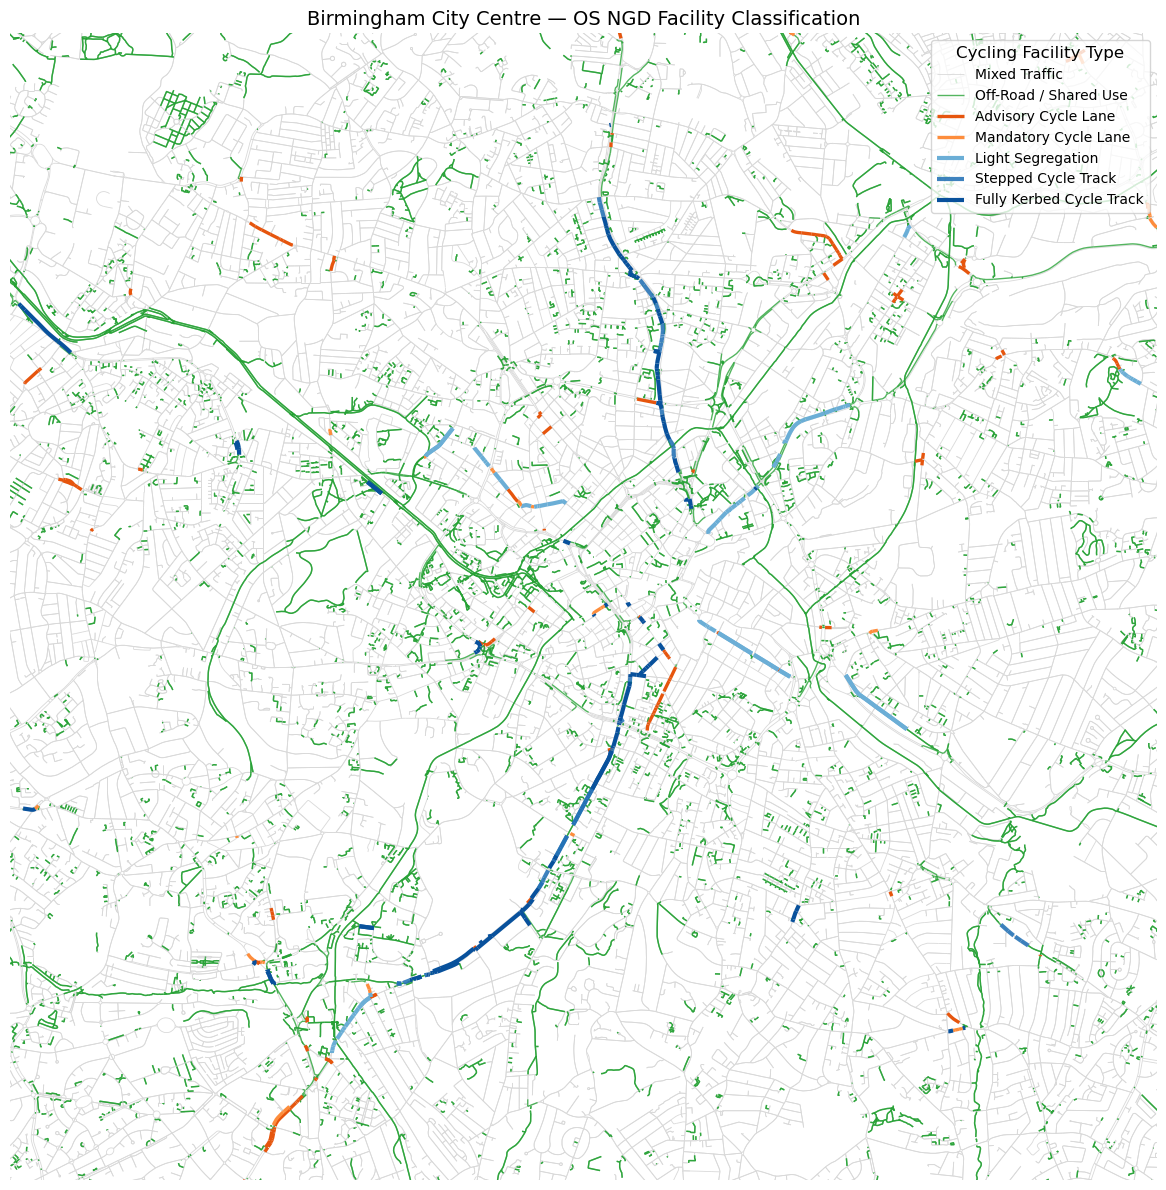

In [36]:
# =============================================================================
# Zoomed: Birmingham City Centre — OS NGD (Off-Road + Shared Use merged)
# =============================================================================

cycleable_network_clipped['facility_plot'] = cycleable_network_clipped['facility_type'].replace({
    'Off-Road': 'Off-Road / Shared Use',
    'Shared Use': 'Off-Road / Shared Use',
})

ngd_facility_colors = {
    'Mixed Traffic':             '#d9d9d9',
    'Off-Road / Shared Use':    '#25A134C8',
    'Fully Kerbed Cycle Track': '#08519c',
    'Stepped Cycle Track':      '#2170b5de',
    'Light Segregation':        '#6baed6',
    'Mandatory Cycle Lane':     '#fd8d3c',
    'Advisory Cycle Lane':      '#e6550d',
}

ngd_facility_lw = {
    'Mixed Traffic':             0.3,
    'Off-Road / Shared Use':    0.5,
    'Fully Kerbed Cycle Track': 1.5,
    'Stepped Cycle Track':      1.5,
    'Light Segregation':        1.5,
    'Mandatory Cycle Lane':     1.2,
    'Advisory Cycle Lane':      1.2,
}

ngd_plot_order = [
    'Mixed Traffic',
    'Off-Road / Shared Use',
    'Advisory Cycle Lane',
    'Mandatory Cycle Lane',
    'Light Segregation',
    'Stepped Cycle Track',
    'Fully Kerbed Cycle Track',
]

bham_cx, bham_cy = 406500, 286500
radius = 5000

fig, ax = plt.subplots(figsize=(12, 12))

for ftype in ngd_plot_order:
    subset = cycleable_network_clipped[cycleable_network_clipped['facility_plot'] == ftype]
    if len(subset) > 0:
        subset.plot(ax=ax, color=ngd_facility_colors[ftype],
                    linewidth=ngd_facility_lw[ftype] * 2, label=ftype)

ax.set_xlim(bham_cx - radius, bham_cx + radius)
ax.set_ylim(bham_cy - radius, bham_cy + radius)

ax.legend(loc='upper right', title='Cycling Facility Type', fontsize=10, title_fontsize=12)
ax.set_title('Birmingham City Centre — OS NGD Facility Classification', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

### A.3 OSM: extraction and facility classification

In [37]:
# =============================================================================
# Read OSM cycling network
# =============================================================================
edges = gpd.read_parquet(DATA_DIR / "cycling_network_processed.parquet")

def filter_unsuitable_highways(edges):
    """
    Pre-process road network to exclude highway types that are
    mis-specified, misspelled in OSM, or unsuitable for cycling.

    Based on Jeong & Smith (2025), extended for West Midlands data.

    Excluded categories:
    - Motorways and motorway links (legally prohibited for cycling)
    - Construction / proposed / planned (not yet built)
    - Common OSM misspellings (e.g. 'cycleway way')
    - Invalid or non-cyclable tags found in study area
      (no, steps, services, raceway, emergency_bay, bus_stop)
    """
    exclude_exact = {
        'motorway', 'motorway_link',
        'construction', 'proposed', 'planned',
        'cycleway way',
        'no', 'steps', 'services', 'raceway', 'emergency_bay', 'bus_stop',
    }

    highway = edges['highway'].astype(str).str.strip().str.lower()
    mask_exclude = highway.isin(exclude_exact)

    n_before = len(edges)
    edges_filtered = edges[~mask_exclude].copy()
    n_after = len(edges_filtered)

    print(f"Highway filtering: {n_before} -> {n_after} edges "
          f"({n_before - n_after} removed)")

    if mask_exclude.any():
        print("\nRemoved highway types:")
        print(edges.loc[mask_exclude, 'highway'].value_counts().to_string())

    return edges_filtered



def expand_directed(edges):
    """Expand OSM edges into directed edges based on oneway attribute."""
    forward = edges.copy()
    forward['edge_dir'] = 'forward'
    
    # Reverse edges for bidirectional segments
    reverse = edges[edges['oneway'] != 'yes'].copy()
    reverse['edge_dir'] = 'reverse'
    reverse['geometry'] = reverse.geometry.reverse()
    
    directed = pd.concat([forward, reverse], ignore_index=True)
    print(f"Direction expansion: {len(edges)} -> {len(directed)} edges")
    return directed

def classify_osm_facility(edges):
    """
    Classify OSM edges into facility types comparable to OS NGD categories.
    
    OSM wiki references:
    - highway=cycleway: dedicated cycleway (standalone)
    - cycleway=track: physically separated cycle track alongside road
    - cycleway=lane: mandatory on-road cycle lane (OSM convention)
    - cycleway=advisory/shared_lane: advisory on-road cycle lane
    - cycleway=share_busway: shared bus lane (treated as Mixed Traffic)
    - cycleway=separate/sidepath: separate cycle track referenced from road
    - bicycle=use_sidepath: cyclists directed to use adjacent sidepath
    - highway=path/footway + bicycle=designated: shared use
    - highway=path/footway + bicycle=yes/permissive: permissive off-road
    
    Key limitations vs OS NGD:
    - Cannot distinguish fully kerbed / stepped / light segregation
      — all map to Cycle Track (undifferentiated)
    - Mandatory vs advisory split follows OSM convention but many mappers
      tag advisory lanes as cycleway=lane, so mandatory may be overcounted
    """
    edges = edges.copy()
    
    hw = edges['highway'].astype(str).str.strip().str.lower()
    
    def safe_str(col):
        if col in edges.columns:
            return edges[col].astype(str).str.strip().str.lower()
        return pd.Series('nan', index=edges.index)
    
    cw       = safe_str('cycleway')
    cw_left  = safe_str('cycleway:left')
    cw_right = safe_str('cycleway:right')
    cw_both  = safe_str('cycleway:both')
    bicycle  = safe_str('bicycle')
    foot     = safe_str('foot')
    
    # Initialise as Mixed Traffic
    facility = pd.Series('Mixed Traffic', index=edges.index)
    
    is_path = hw.isin(['path', 'footway', 'bridleway'])
    
    # 1. Off-Road (path/footway/bridleway with bicycle=yes/permissive)
    facility[is_path & bicycle.isin(['yes', 'permissive'])] = 'Off-Road'
    
    # 2. Shared Use (path/footway/bridleway with bicycle=designated,
    #    or highway=cycleway + foot=designated/yes)
    facility[is_path & bicycle.eq('designated')] = 'Shared Use'
    facility[(hw == 'cycleway') & foot.isin(['designated', 'yes'])] = 'Shared Use'
    
    # 3. Standalone cycleway (highway=cycleway, no foot sharing)
    facility[(hw == 'cycleway') & ~foot.isin(['designated', 'yes'])] = 'Cycle Track (undifferentiated)'
    
    # 4. Separate/sidepath cycleway referenced from road
    has_separate = (
        cw.isin(['separate', 'sidepath']) |
        cw_left.isin(['separate', 'sidepath']) |
        cw_right.isin(['separate', 'sidepath']) |
        cw_both.isin(['separate', 'sidepath']) |
        bicycle.eq('use_sidepath')
    )
    facility[has_separate & ~is_path] = 'Cycle Track (undifferentiated)'
    
    # 5. On-road cycle track (cycleway=track on any side)
    has_track = (
        cw.eq('track') |
        cw_left.eq('track') | cw_right.eq('track') |
        cw_both.eq('track')
    )
    facility[has_track & ~is_path] = 'Cycle Track (undifferentiated)'
    
    # 6a. Mandatory cycle lane (cycleway=lane per OSM convention)
    has_mandatory = (
        cw.isin(['lane', 'opposite_lane']) |
        cw_left.isin(['lane', 'opposite_lane']) | cw_right.isin(['lane', 'opposite_lane']) |
        cw_both.isin(['lane', 'opposite_lane'])
    )
    facility[has_mandatory & ~is_path] = 'Mandatory Cycle Lane'
    
    # 6b. Advisory cycle lane
    has_advisory = (
        cw.isin(['advisory', 'shared_lane']) |
        cw_left.isin(['advisory', 'shared_lane']) | cw_right.isin(['advisory', 'shared_lane']) |
        cw_both.isin(['advisory', 'shared_lane'])
    )
    facility[has_advisory & ~is_path] = 'Advisory Cycle Lane'
    
    # 7. Shared bus lane → Mixed Traffic (no dedicated cycling provision)
    has_busway = (
        cw.eq('share_busway') |
        cw_left.eq('share_busway') | cw_right.eq('share_busway') |
        cw_both.eq('share_busway')
    )
    facility[has_busway] = 'Mixed Traffic'
    
    edges['facility_type_osm'] = facility
    
    print(edges['facility_type_osm'].value_counts().to_string())
    return edges



edges = filter_unsuitable_highways(edges)
edges = expand_directed(edges)
edges = classify_osm_facility(edges)

Highway filtering: 141992 -> 141951 edges (41 removed)

Removed highway types:
highway
steps            30
services          5
no                2
raceway           1
emergency_bay     1
bus_stop          1
construction      1
Direction expansion: 141951 -> 263688 edges
facility_type_osm
Mixed Traffic                     246012
Shared Use                         11349
Cycle Track (undifferentiated)      2569
Off-Road                            1761
Advisory Cycle Lane                 1127
Mandatory Cycle Lane                 870


### A.4 OSM: Birmingham city centre map

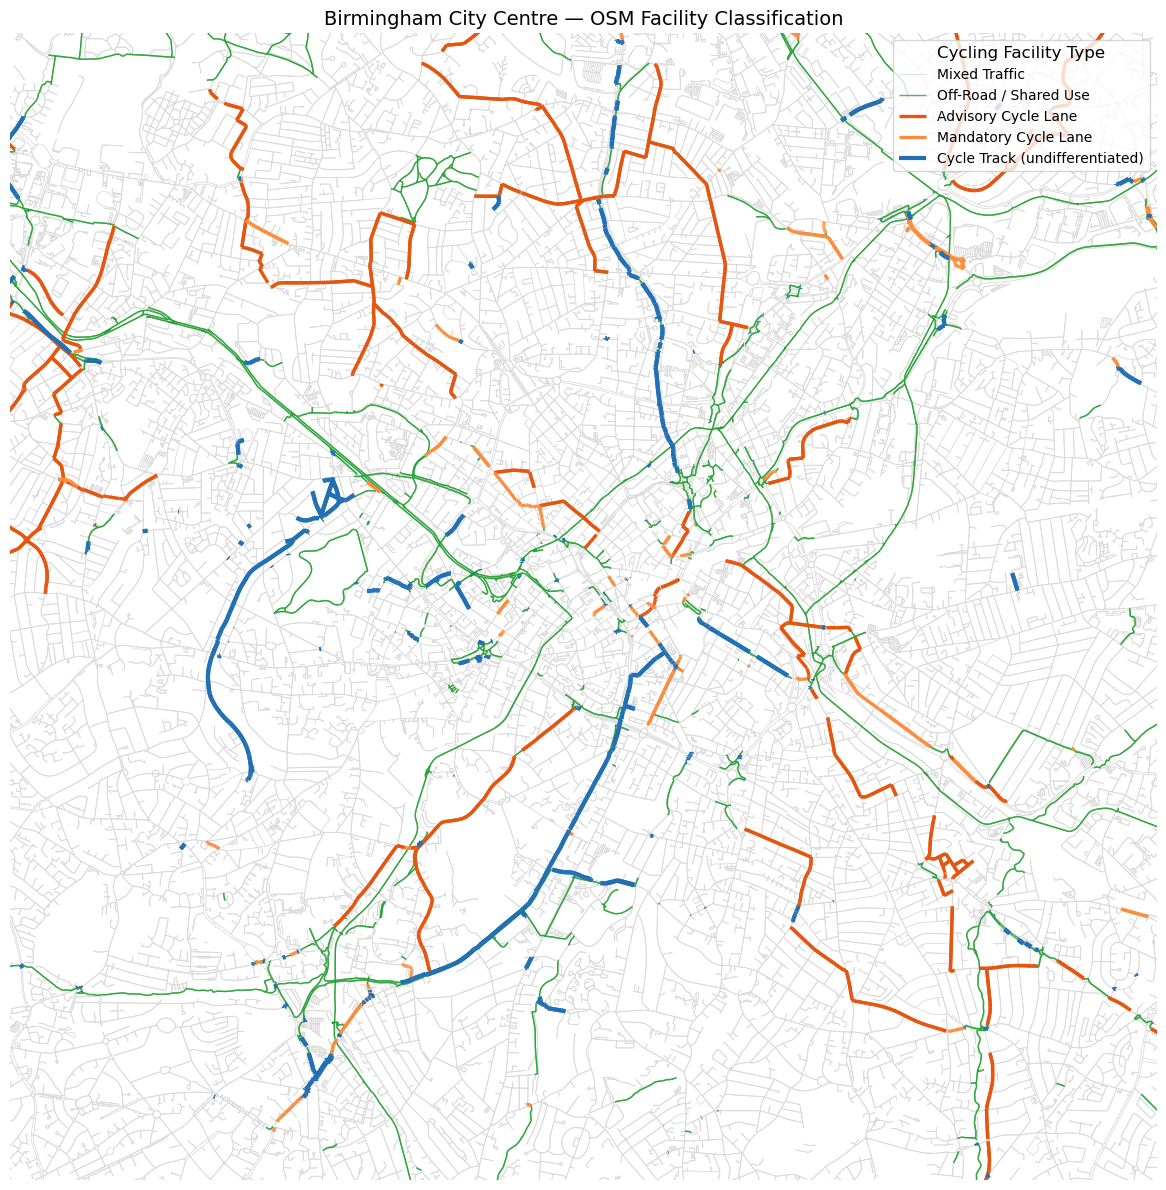

In [38]:
# =============================================================================
# Zoomed: Birmingham City Centre — OSM (Off-Road + Shared Use merged)
# =============================================================================

osm_facility_colors = {
    'Mixed Traffic':                   '#d9d9d9',
    'Off-Road / Shared Use':          '#25A134C8',
    'Cycle Track (undifferentiated)':  '#2170b5',
    'Mandatory Cycle Lane':            '#fd8d3c',
    'Advisory Cycle Lane':             '#e6550d',
}

osm_facility_lw = {
    'Mixed Traffic':                   0.3,
    'Off-Road / Shared Use':          0.5,
    'Cycle Track (undifferentiated)':  1.5,
    'Mandatory Cycle Lane':            1.2,
    'Advisory Cycle Lane':             1.2,
}

osm_plot_order = [
    'Mixed Traffic',
    'Off-Road / Shared Use',
    'Advisory Cycle Lane',
    'Mandatory Cycle Lane',
    'Cycle Track (undifferentiated)',
]

# Merge facility types
edges['facility_plot'] = edges['facility_type_osm'].replace({
    'Off-Road': 'Off-Road / Shared Use',
    'Shared Use': 'Off-Road / Shared Use',
})

bham_cx, bham_cy = 406500, 286500
radius = 5000

fig, ax = plt.subplots(figsize=(12, 12))

for ftype in osm_plot_order:
    subset = edges[edges['facility_plot'] == ftype]
    if len(subset) > 0:
        subset.plot(ax=ax, color=osm_facility_colors[ftype],
                    linewidth=osm_facility_lw[ftype] * 2, label=ftype)

ax.set_xlim(bham_cx - radius, bham_cx + radius)
ax.set_ylim(bham_cy - radius, bham_cy + radius)

ax.legend(loc='upper right', title='Cycling Facility Type', fontsize=10, title_fontsize=12)
ax.set_title('Birmingham City Centre — OSM Facility Classification', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

### A.5 OS NGD vs OSM: aggregated comparison table

In [39]:
# ── OSM Birmingham comparison ──────────────────────────────────────

# Clip OSM to Birmingham
bham_osm = edges[
    edges.geometry.centroid.within(bham_geom)
].copy()
bham_osm['geometry_length_m'] = bham_osm.geometry.length  # BNG = metres

print(f"OSM Birmingham directed edges: {len(bham_osm):,}")
print(f"OSM Birmingham directed length: {bham_osm['geometry_length_m'].sum() / 1000:.1f} km\n")

# ── Undirected: deduplicate by osmid ───────────────────────────────
# OSM edges have forward/reverse from expand_directed
osm_undir = (
    bham_osm
    .groupby(['id', 'facility_type_osm'])
    .agg(link_length_m=('geometry_length_m', 'first'))
    .reset_index()
)

osm_facility = (
    osm_undir
    .groupby('facility_type_osm')
    .agg(
        unique_links=('id', 'count'),
        undirected_km=('link_length_m', lambda x: x.sum() / 1000)
    )
    .sort_values('undirected_km', ascending=False)
)
osm_facility['pct'] = osm_facility['undirected_km'] / osm_facility['undirected_km'].sum() * 100

print("=" * 65)
print("OSM BIRMINGHAM — Facility type (undirected km)")
print("=" * 65)
print(osm_facility.to_string(float_format='{:.2f}'.format))

# ── Aggregated comparison table ────────────────────────────────────
# Map both OS and OSM to common categories
def aggregate_category(ft):
    paint = ['Advisory Cycle Lane', 'Mandatory Cycle Lane']
    separated_os = ['Fully Kerbed Cycle Track', 'Stepped Cycle Track', 'Light Segregation']
    separated_osm = ['Cycle Track (undifferentiated)']
    shared = ['Shared Use']
    offroad = ['Off-Road']
    if ft in paint:
        return 'Paint-only (advisory + mandatory)'
    elif ft in separated_os + separated_osm:
        return 'Physically separated'
    elif ft in shared:
        return 'Shared use'
    elif ft in offroad:
        return 'Off-road'
    else:
        return 'Mixed traffic'

# OS NGD (reuse bham_undir from previous cell)
os_agg = bham_undir.copy()
os_agg['category'] = os_agg['facility_type'].map(aggregate_category)
os_summary = os_agg.groupby('category')['link_length_m'].sum() / 1000

# OSM
osm_agg = osm_undir.copy()
osm_agg['category'] = osm_agg['facility_type_osm'].map(aggregate_category)
osm_summary = osm_agg.groupby('category')['link_length_m'].sum() / 1000

# Combine
comparison = pd.DataFrame({
    'OS_NGD_km': os_summary,
    'OSM_km': osm_summary
}).fillna(0)
comparison['ratio'] = comparison['OS_NGD_km'] / comparison['OSM_km'].replace(0, float('nan'))

print("\n" + "=" * 65)
print("BIRMINGHAM — OS NGD vs OSM by aggregated category (undirected km)")
print("=" * 65)
print(comparison.to_string(float_format='{:.2f}'.format))
print(f"\n{'':30s} OS NGD    OSM     ratio")
print(f"{'TOTAL':30s} {comparison['OS_NGD_km'].sum():7.1f}  {comparison['OSM_km'].sum():7.1f}  {comparison['OS_NGD_km'].sum()/comparison['OSM_km'].sum():.3f}")

OSM Birmingham directed edges: 74,595
OSM Birmingham directed length: 8123.8 km

OSM BIRMINGHAM — Facility type (undirected km)
                                unique_links  undirected_km   pct
facility_type_osm                                                
Mixed Traffic                          37429        3959.56 91.28
Shared Use                              1828         233.84  5.39
Cycle Track (undifferentiated)           610          57.15  1.32
Advisory Cycle Lane                      249          44.23  1.02
Mandatory Cycle Lane                     250          27.24  0.63
Off-Road                                 163          16.02  0.37

BIRMINGHAM — OS NGD vs OSM by aggregated category (undirected km)
                                   OS_NGD_km  OSM_km  ratio
category                                                   
Mixed traffic                        2772.92 3959.56   0.70
Off-road                               42.76   16.02   2.67
Paint-only (advisory + mandatory)    

### A.6 OS NGD capture-method diagnostics

OS NGD records how each attribute was captured. These checks confirm that the on-street cycle lanes recorded by OS NGD come predominantly from automated aerial-imagery capture, which explains the coverage gap against the surveyed OSM and TfWM networks.

In [40]:
painted = cycleable_network[
    cycleable_network['facility_type'].isin(['Advisory Cycle Lane', 'Mandatory Cycle Lane'])
]

print(f"Total painted lanes: {len(painted)}")
print("\nCapture method:")
print(painted['presenceofcyclelane_capturemethod'].value_counts(dropna=False))
print("\nSource:")
print(painted['presenceofcyclelane_updatedate'].value_counts(dropna=False).head(10))

Total painted lanes: 1280

Capture method:
presenceofcyclelane_capturemethod
Automated Process    1280
Name: count, dtype: int64

Source:
presenceofcyclelane_updatedate
2999-12-25    1270
2026-03-28       5
2026-02-05       3
2026-05-01       2
Name: count, dtype: int64


In [41]:
# Check capture method for ALL facility types
print("=== Cycle Lane Capture Method by Facility Type ===")
print(
    cycleable_network
    .groupby('facility_type')['presenceofcyclelane_capturemethod']
    .value_counts(dropna=False)
    .to_string()
)

# Check update dates for all types
print("\n=== Update Dates by Facility Type ===")
print(
    cycleable_network
    .groupby('facility_type')['presenceofcyclelane_updatedate']
    .value_counts(dropna=False)
    .head(30)
    .to_string()
)

# Also check: is road width / pavement from automated or surveyed?
print("\n=== Road Width Confidence Level ===")
print(cycleable_network['roadwidth_confidencelevel'].value_counts(dropna=False))

print("\n=== Pavement Capture Method ===")
print(cycleable_network['presenceofpavement_capturemethod'].value_counts(dropna=False))

print("\n=== Street Light Capture Method ===")
print(cycleable_network['presenceofstreetlight_capturemethod'].value_counts(dropna=False))

=== Cycle Lane Capture Method by Facility Type ===
facility_type             presenceofcyclelane_capturemethod
Advisory Cycle Lane       Automated Process                      1132
Fully Kerbed Cycle Track  Automated Process                       681
Light Segregation         Automated Process                       146
Mandatory Cycle Lane      Automated Process                       148
Mixed Traffic             Automated Process                    383335
Off-Road                  Automated Process                     90046
Shared Use                Automated Process                      4668
Stepped Cycle Track       Automated Process                        72

=== Update Dates by Facility Type ===
facility_type             presenceofcyclelane_updatedate
Advisory Cycle Lane       2999-12-25                          1124
                          2026-03-28                             5
                          2026-05-01                             2
                          2026-0